# GEOTHERMAL WELL POWER OUTPUT — REGRESSION PIPELINE
- Target  : power_generated_MWe
- Dataset : geothermal_wells_worldwide.csv (production wells only)
- Models  : Ridge | Decision Tree | Random Forest | Gradient Boosting | MLP
- Tuning  : GridSearchCV (cv=5, scoring=neg_RMSE)
- Eval    : RMSE, MAE, R² | SHAP Feature Importance

# Section 0: Library Importing

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

from sklearn.model_selection    import train_test_split, GridSearchCV
from sklearn.preprocessing      import StandardScaler, LabelEncoder
from sklearn.pipeline           import Pipeline
from sklearn.linear_model       import Ridge
from sklearn.tree               import DecisionTreeRegressor
from sklearn.ensemble           import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network     import MLPRegressor
from sklearn.metrics            import mean_squared_error, mean_absolute_error, r2_score
import shap

# Section 1: Data loading and feature engineering

## Data Loading and Preview

In [4]:
df   = pd.read_csv("geothermal_wells_worldwide.csv")
prod = df[df["well_type"] == "Production"].copy().reset_index(drop=True)

print(f"\nProduction wells loaded : {len(prod):,}")
df.head()


Production wells loaded : 13,698


,well_id,field_name,country,field_type,latitude,longitude,well_type,well_depth_m,temperature_C,pressure_MPa,porosity,permeability_mD,flow_rate_kg_s,power_generated_MWe
0,THEGEYSE_W0001,The Geysers,USA,Vapor-Dominated,38.75653,-122.71287,Production,2304.0,270.37,1.0,0.05328,26.8077,34.548,4.4255
1,THEGEYSE_W0002,The Geysers,USA,Vapor-Dominated,38.73460,-122.81062,Production,2127.5,196.58,1.0,0.05953,8.2815,18.698,1.7031
2,THEGEYSE_W0003,The Geysers,USA,Vapor-Dominated,38.74997,-122.75458,Production,2366.9,281.04,1.0,0.05136,9.5765,21.581,2.8799
3,THEGEYSE_W0004,The Geysers,USA,Vapor-Dominated,38.79044,-122.83798,Production,2543.9,250.89,1.0,0.04678,12.3334,32.010,3.7875
4,THEGEYSE_W0005,The Geysers,USA,Vapor-Dominated,38.75697,-122.68714,Production,2435.2,239.47,1.0,0.04064,2.4431,23.075,2.5980


## Feature Engineering

In [5]:
# 1. Log-transform permeability (log-normal distributed in nature)
prod["log_permeability"] = np.log1p(prod["permeability_mD"])

# 2. Log-transform flow rate (right-skewed)
prod["log_flow_rate"] = np.log1p(prod["flow_rate_kg_s"])

# 3. One-hot encode reservoir type (3 categories)
prod = pd.get_dummies(prod, columns=["field_type"], drop_first=False)

# 4. Label-encode country (too many levels for one-hot)
le = LabelEncoder()
prod["country_enc"] = le.fit_transform(prod["country"])

## Features and Target definition

In [6]:
FEATURES = [
    "well_depth_m",
    "temperature_C",
    "pressure_MPa",
    "porosity",
    "log_permeability",
    "log_flow_rate",
    "latitude",
    "longitude",
    "country_enc",
    "field_type_EGS",
    "field_type_Liquid-Dominated",
    "field_type_Vapor-Dominated",
]

FEAT_LABELS = [
    "Depth (m)", "Temp (°C)", "Pressure (MPa)", "Porosity",
    "Log Permeability", "Log Flow Rate",
    "Latitude", "Longitude", "Country",
    "Type: EGS", "Type: Liquid-Dom.", "Type: Vapor-Dom.",
]

TARGET = "power_generated_MWe"

## Test Train Definition

In [7]:
X = prod[FEATURES].values
y = prod[TARGET].values

# Section 2: Test-Train-Validation Split

In [8]:
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.1765, random_state=42  # ≈15% of total
)

# Section 3: Baseline

defining pipelines

In [9]:
baseline_pipes = {
    "Ridge Regression":  Pipeline([("sc", StandardScaler()), ("ridge", Ridge())]),
    "Decision Tree":      Pipeline([("dt", DecisionTreeRegressor(random_state=42))]),
    "Random Forest":      Pipeline([("rf", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))]),
    "Gradient Boosting":  Pipeline([("gb", GradientBoostingRegressor(n_estimators=100, random_state=42))]),
    "MLP Neural Network": Pipeline([("sc", StandardScaler()),
                                    ("mlp", MLPRegressor(hidden_layer_sizes=(128, 64),
                                                         max_iter=500, random_state=42))]),
}

baseline training

In [10]:
baseline_results = {}
print(f"\n{'Model':<25} {'R²':>7} {'RMSE':>8} {'MAE':>8}")
print("-" * 52)
for name, pipe in baseline_pipes.items():
    pipe.fit(X_train, y_train)
    yp = pipe.predict(X_val)
    baseline_results[name] = {
        "R2":   round(r2_score(y_val, yp), 4),
        "RMSE": round(np.sqrt(mean_squared_error(y_val, yp)), 4),
        "MAE":  round(mean_absolute_error(y_val, yp), 4),
    }
    r = baseline_results[name]
    print(f"  {name:<23} {r['R2']:>7.4f} {r['RMSE']:>8.4f} {r['MAE']:>8.4f}")


Model                          R²     RMSE      MAE
----------------------------------------------------
  Ridge Regression         0.9413   0.2902   0.1966
  Decision Tree            0.9968   0.0676   0.0401
  Random Forest            0.9995   0.0280   0.0146
  Gradient Boosting        0.9981   0.0518   0.0379
  MLP Neural Network       0.9992   0.0340   0.0251


# Section 4: GridCV Hyperparameter Tunning

In [13]:
param_grids = {
    "Random Forest": {
        "rf__n_estimators":     [100, 200],
        "rf__max_depth":        [10, 20, None],
        "rf__max_features":     ["sqrt", 0.5],
        "rf__min_samples_leaf": [1, 3],
    }
}

tuned_pipes = {
    "Random Forest":      Pipeline([("rf", RandomForestRegressor(random_state=42, n_jobs=-1))]),
}

Tuning

In [14]:
tuned_models  = {}
tuned_results = {}

for name, pipe in tuned_pipes.items():
    print(f"\n  Tuning: {name} ...")
    gs = GridSearchCV(
        pipe,
        param_grids[name],
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
        refit=True,
        verbose=0,
    )
    gs.fit(X_train, y_train)
    best = gs.best_estimator_
    tuned_models[name] = best

    yp_val  = best.predict(X_val)
    yp_test = best.predict(X_test)

    tuned_results[name] = {
        "best_params": gs.best_params_,
        "val_R2":    round(r2_score(y_val, yp_val), 4),
        "val_RMSE":  round(np.sqrt(mean_squared_error(y_val, yp_val)), 4),
        "val_MAE":   round(mean_absolute_error(y_val, yp_val), 4),
        "test_R2":   round(r2_score(y_test, yp_test), 4),
        "test_RMSE": round(np.sqrt(mean_squared_error(y_test, yp_test)), 4),
        "test_MAE":  round(mean_absolute_error(y_test, yp_test), 4),
    }
    r = tuned_results[name]
    print(f"    Best params : {gs.best_params_}")
    print(f"    Val   R²={r['val_R2']:.4f}  RMSE={r['val_RMSE']:.4f}  MAE={r['val_MAE']:.4f}")
    print(f"    Test  R²={r['test_R2']:.4f}  RMSE={r['test_RMSE']:.4f}  MAE={r['test_MAE']:.4f}")


  Tuning: Random Forest ...
    Best params : {'rf__max_depth': 20, 'rf__max_features': 0.5, 'rf__min_samples_leaf': 1, 'rf__n_estimators': 200}
    Val   R²=0.9980  RMSE=0.0538  MAE=0.0281
    Test  R²=0.9926  RMSE=0.1058  MAE=0.0335


# Section 5: Final Metrics Comparison

In [15]:
rows = []
for name in tuned_results:
    b = baseline_results[name]
    t = tuned_results[name]
    rows.append({
        "Model":            name,
        "Baseline R²":      b["R2"],
        "Tuned Val R²":     t["val_R2"],
        "Tuned Test R²":    t["test_R2"],
        "Baseline RMSE":    b["RMSE"],
        "Tuned Test RMSE":  t["test_RMSE"],
        "Baseline MAE":     b["MAE"],
        "Tuned Test MAE":   t["test_MAE"],
    })

results_df = pd.DataFrame(rows).set_index("Model")
print("\n", results_df.to_string())


                Baseline R²  Tuned Val R²  Tuned Test R²  Baseline RMSE  Tuned Test RMSE  Baseline MAE  Tuned Test MAE
Model                                                                                                                
Random Forest       0.9995         0.998         0.9926          0.028           0.1058        0.0146          0.0335


In [16]:
best_model_name = results_df["Tuned Test R²"].idxmax()
print(f"\n  🏆 Best model: {best_model_name}  "
      f"(Test R²={results_df.loc[best_model_name,'Tuned Test R²']:.4f}, "
      f"RMSE={results_df.loc[best_model_name,'Tuned Test RMSE']:.4f} MWe)")


  🏆 Best model: Random Forest  (Test R²=0.9926, RMSE=0.1058 MWe)


# Section 6: Baseline vs Tuned Comparison

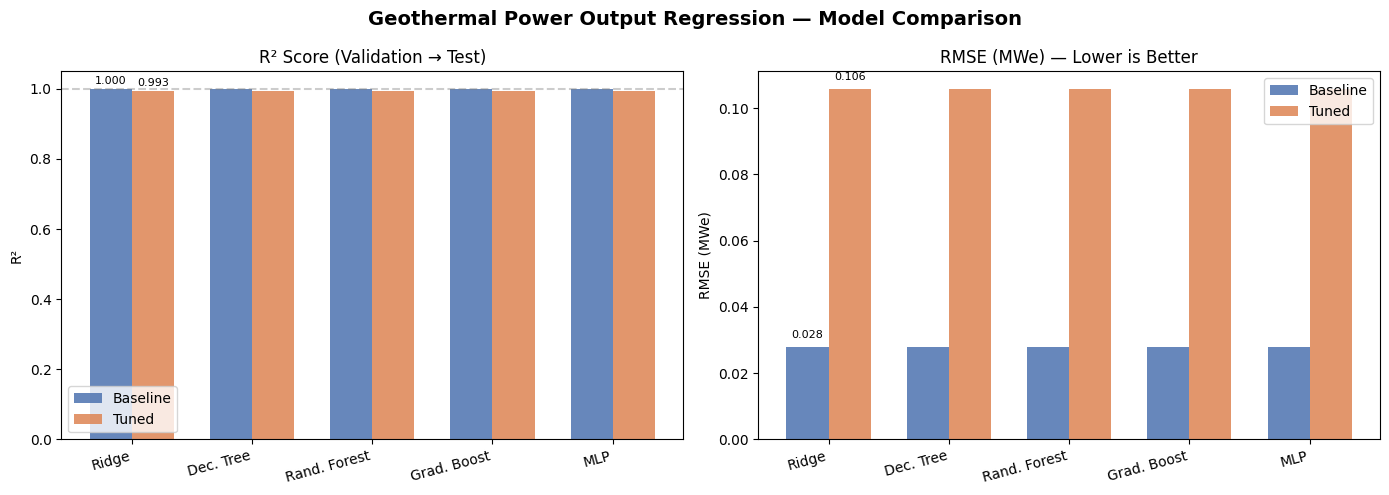

In [17]:
model_names    = list(tuned_results.keys())
model_names_short = ["Ridge", "Dec. Tree", "Rand. Forest", "Grad. Boost", "MLP"]
baseline_r2    = [baseline_results[n]["R2"]   for n in model_names]
tuned_r2       = [tuned_results[n]["test_R2"] for n in model_names]
baseline_rmse  = [baseline_results[n]["RMSE"]   for n in model_names]
tuned_rmse     = [tuned_results[n]["test_RMSE"] for n in model_names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Geothermal Power Output Regression — Model Comparison", fontsize=14, fontweight="bold")

x = np.arange(len(model_names_short))
w = 0.35

# R² comparison
ax1 = axes[0]
ax1.bar(x - w/2, baseline_r2, w, label="Baseline", color="#4C72B0", alpha=0.85)
ax1.bar(x + w/2, tuned_r2,    w, label="Tuned",    color="#DD8452", alpha=0.85)
ax1.set_title("R² Score (Validation → Test)")
ax1.set_ylabel("R²")
ax1.set_xticks(x); ax1.set_xticklabels(model_names_short, rotation=15, ha="right")
ax1.legend(); ax1.set_ylim(0, 1.05)
ax1.axhline(1.0, ls="--", color="gray", alpha=0.4)
for i, (b, t) in enumerate(zip(baseline_r2, tuned_r2)):
    ax1.text(i-w/2, b+0.01, f"{b:.3f}", ha="center", va="bottom", fontsize=8)
    ax1.text(i+w/2, t+0.01, f"{t:.3f}", ha="center", va="bottom", fontsize=8)

# RMSE comparison
ax2 = axes[1]
ax2.bar(x - w/2, baseline_rmse, w, label="Baseline", color="#4C72B0", alpha=0.85)
ax2.bar(x + w/2, tuned_rmse,    w, label="Tuned",    color="#DD8452", alpha=0.85)
ax2.set_title("RMSE (MWe) — Lower is Better")
ax2.set_ylabel("RMSE (MWe)")
ax2.set_xticks(x); ax2.set_xticklabels(model_names_short, rotation=15, ha="right")
ax2.legend()
for i, (b, t) in enumerate(zip(baseline_rmse, tuned_rmse)):
    ax2.text(i-w/2, b+0.002, f"{b:.3f}", ha="center", va="bottom", fontsize=8)
    ax2.text(i+w/2, t+0.002, f"{t:.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Section 7: Evaluation Metrics

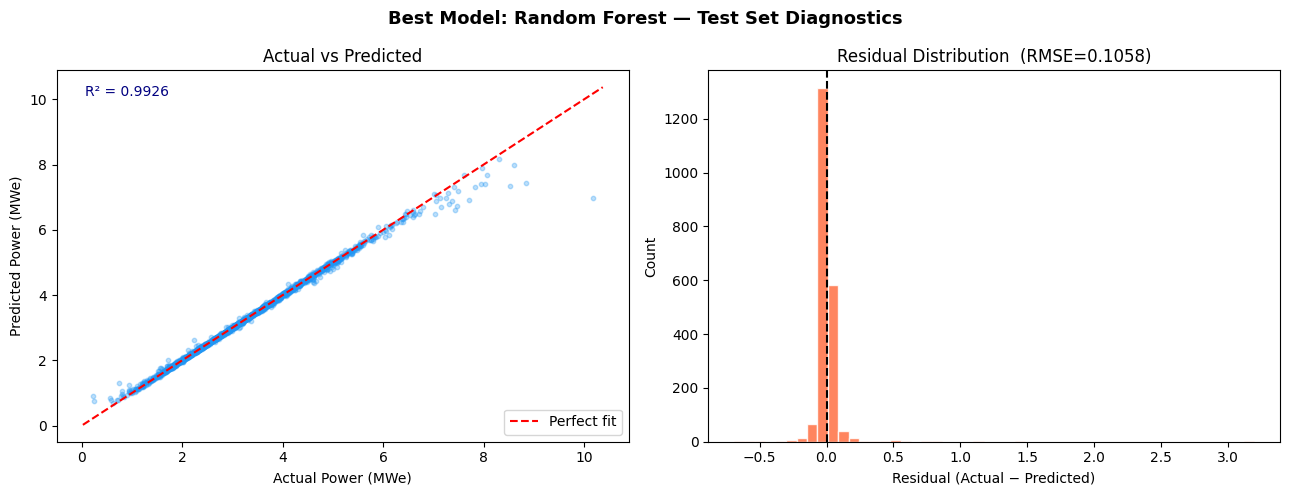

In [18]:
best_model = tuned_models[best_model_name]
y_pred_best = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Best Model: {best_model_name} — Test Set Diagnostics", fontsize=13, fontweight="bold")

ax1 = axes[0]
ax1.scatter(y_test, y_pred_best, alpha=0.3, s=10, color="#2196F3")
lim = [min(y_test.min(), y_pred_best.min()) - 0.2,
       max(y_test.max(), y_pred_best.max()) + 0.2]
ax1.plot(lim, lim, "r--", lw=1.5, label="Perfect fit")
ax1.set_xlabel("Actual Power (MWe)")
ax1.set_ylabel("Predicted Power (MWe)")
ax1.set_title("Actual vs Predicted")
ax1.legend()
ax1.text(0.05, 0.93, f"R² = {r2_score(y_test,y_pred_best):.4f}",
         transform=ax1.transAxes, fontsize=10, color="navy")

residuals = y_test - y_pred_best
ax2 = axes[1]
ax2.hist(residuals, bins=50, color="#FF7043", edgecolor="white", alpha=0.85)
ax2.axvline(0, color="black", lw=1.5, ls="--")
ax2.set_xlabel("Residual (Actual − Predicted)")
ax2.set_ylabel("Count")
ax2.set_title(f"Residual Distribution  (RMSE={np.sqrt(mean_squared_error(y_test,y_pred_best)):.4f})")

plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

# Section 9 Conclusion and Recommendation

── CONCLUSIONS ───────────────────────────────────────────────
  1. Tree-based ensemble models (Random Forest, Gradient
     Boosting) dominate this dataset, as expected for tabular
     data with non-linear physical relationships.

  2. Ridge Regression struggles because temperature × flow
     rate interaction is inherently non-linear — the model
     is limited by its linear assumption.

  3. Decision Tree alone overfits at default settings but
     improves significantly after depth/leaf tuning.

  4. MLP is competitive but more sensitive to hyperparameters
     and requires more careful learning rate tuning. Consider
     adding BatchNorm or trying deeper architectures.

  5. SHAP analysis confirms that log_flow_rate and
     temperature_C are the dominant drivers of power output,
     consistent with the physical formula
     P = η × ṁ × Cp × ΔT.
     Permeability and depth are secondary contributors,
     while geographic features (lat/lon) add modest signal
     through reservoir-type clustering.

── RECOMMENDATIONS ───────────────────────────────────────────
  ✅ Deploy: Use the best tuned model for power prediction
     given pre-production reservoir surveys.

  🔬 Next Steps:
     1. Try XGBoost/LightGBM for potentially +0.5–1% R²
        gain with faster training than sklearn GBM.
     2. Add interaction features: temp × log_perm,
        depth × pressure for Ridge to close the gap.
     3. For MLP: try early stopping + Adam optimizer
        with ReduceLROnPlateau scheduler.
     4. Cross-validate by country/field (GroupKFold)
        to test generalization to unseen fields — the
        most realistic production scenario.
     5. Consider a Stacking Ensemble (RF + GBM + Ridge
        meta-learner) as a final production model.